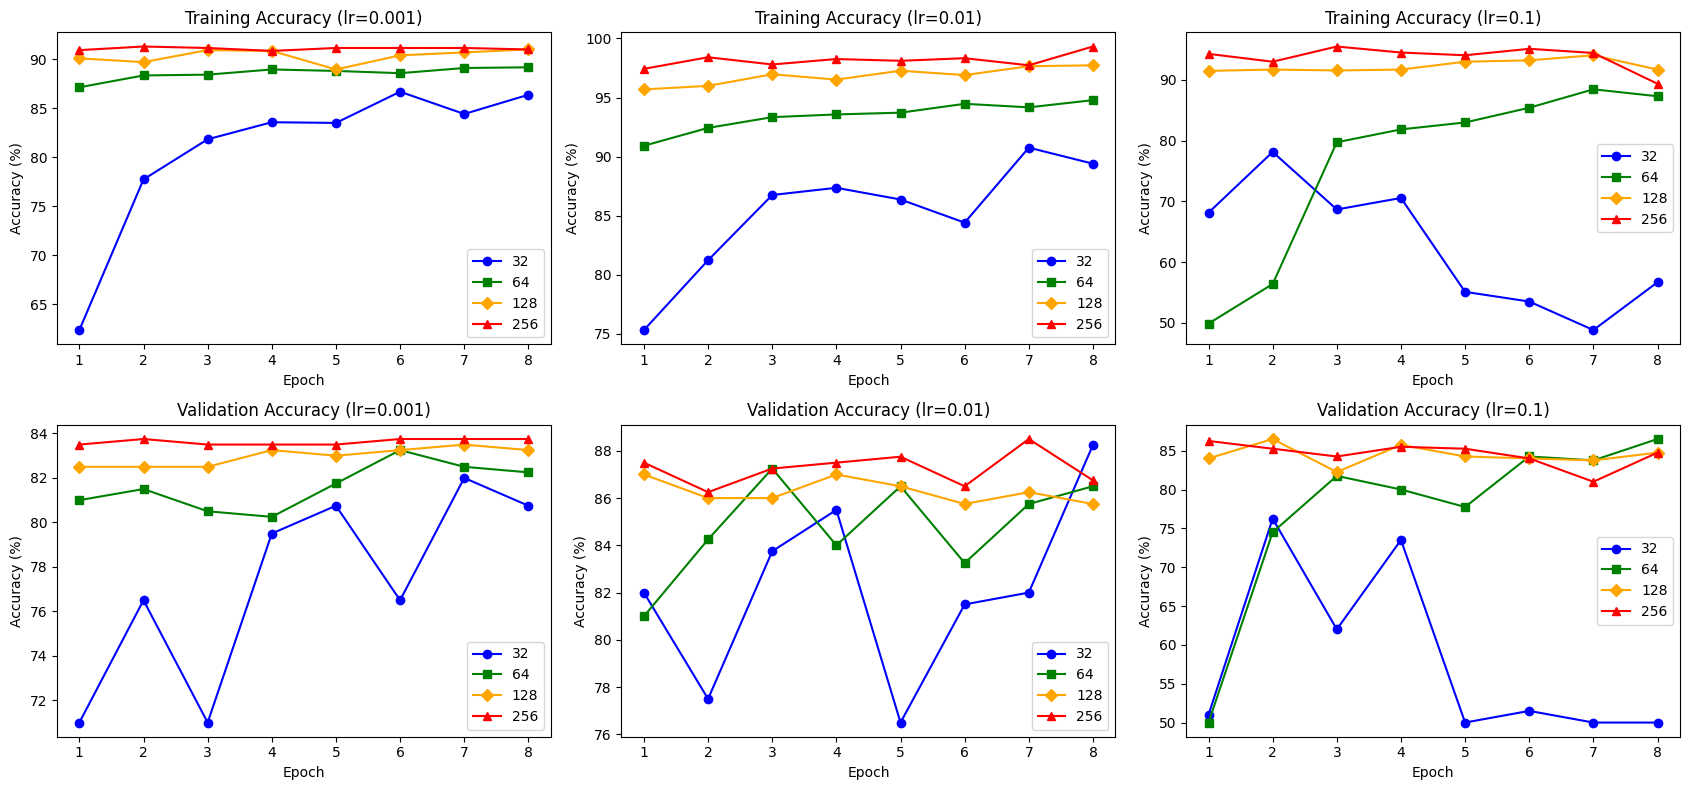

In [ ]:
import matplotlib.pyplot as plt

files = [
    "Batches_lr_0.001_accuracy_results.txt",
    "Batches_lr_0.01_accuracy_results.txt",
    "Batches_lr_0.1_accuracy_results.txt"
]

learning_rates = [0.001, 0.01, 0.1]

data = {}


for file, lr in zip(files, learning_rates):
    data[lr] = {}
    with open(file, "r") as f:
        lines = f.readlines()
        current_batch = None
        for line in lines:
            line = line.strip()  
            if not line:  
                continue
            if line.startswith("Batch Size:"):
                current_batch = line.split(":")[1].strip()
                data[lr][current_batch] = {"training": [], "validation": []}
                continue
            elif current_batch:
                parts = line.split()
                if len(parts) == 3:
                    try:
                        epoch, train_acc, val_acc = map(float, parts)
                        data[lr][current_batch]["training"].append(train_acc)
                        data[lr][current_batch]["validation"].append(val_acc)
                    except ValueError:
                        print(f"Error procesando la línea: {line}")
                        continue

fig, axs = plt.subplots(2, 3, figsize=(17, 8))  

colors = {"32": "blue", "64": "green", "128": "orange", "256": "red"}
markers = {"32": "o", "64": "s", "128": "D", "256": "^"}

for i, lr in enumerate(learning_rates):
    ax_train = axs[0, i]
    for optimizer, metrics in data[lr].items():
        ax_train.plot(
            range(1, len(metrics["training"]) + 1),
            metrics["training"],
            label=optimizer,
            color=colors[optimizer],
            marker=markers[optimizer],
        )
    ax_train.set_title(f"Training Accuracy (lr={lr})")
    ax_train.set_xlabel("Epoch")
    ax_train.set_ylabel("Accuracy (%)")
    ax_train.legend()
    ax_train.grid(False)

    ax_val = axs[1, i]
    for optimizer, metrics in data[lr].items():
        ax_val.plot(
            range(1, len(metrics["validation"]) + 1),
            metrics["validation"],
            label=optimizer,
            color=colors[optimizer],
            marker=markers[optimizer],
        )
    ax_val.set_title(f"Validation Accuracy (lr={lr})")
    ax_val.set_xlabel("Epoch")
    ax_val.set_ylabel("Accuracy (%)")
    ax_val.legend()
    ax_val.grid(False)

plt.tight_layout()

plt.savefig("accuracy_results_plot.png")
plt.show()
